In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Makes your charts look clean
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [6]:
# Load the historical trades data
trades = pd.read_excel('historical_data.xlsx')

# Load the fear/greed index data
sentiment = pd.read_excel('fear_greed_index.xlsx')

print('Trades shape:', trades.shape)
print('Sentiment shape:', sentiment.shape)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [7]:
# ── TRADES DATA ──────────────────────────────────────
print('=== TRADES DATA ===')
print(f'Rows: {trades.shape[0]}, Columns: {trades.shape[1]}')
print()
print('Column names:')
print(trades.columns.tolist())
print()
print('Missing values per column:')
print(trades.isnull().sum())
print()
print('Duplicate rows:', trades.duplicated().sum())
print()

# ── SENTIMENT DATA ────────────────────────────────────
print('=== SENTIMENT DATA ===')
print(f'Rows: {sentiment.shape[0]}, Columns: {sentiment.shape[1]}')
print()
print('Missing values per column:')
print(sentiment.isnull().sum())
print()
print('Duplicate rows:', sentiment.duplicated().sum())
print()
print('Sentiment categories available:')
print(sentiment['classification'].value_counts())

=== TRADES DATA ===
Rows: 211224, Columns: 16

Column names:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Missing values per column:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate rows: 0

=== SENTIMENT DATA ===
Rows: 2644, Columns: 4

Missing values per column:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate rows: 0

Sentiment categories available:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          3

In [8]:
# Convert Timestamp IST to datetime (it may already be, but be safe)
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'])

# Extract just the date (drop the time part)
trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

# Do the same for sentiment
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.normalize()

# Check date ranges overlap
print('Trades date range:', trades['date'].min(), 'to', trades['date'].max())
print('Sentiment date range:', sentiment['date'].min(), 'to', sentiment['date'].max())

Trades date range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00
Sentiment date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [9]:
# Merge trades with sentiment on the date column
df = trades.merge(sentiment[['date', 'value', 'classification']], on='date', how='inner')

print('Merged dataframe shape:', df.shape)
print()
print('Sentiment distribution in merged data:')
print(df['classification'].value_counts())
print()
print('Sample merged row:')
print(df[['Account', 'date', 'Closed PnL', 'Side', 'classification']].head(3))

Merged dataframe shape: (211218, 19)

Sentiment distribution in merged data:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Sample merged row:
                                      Account       date  Closed PnL Side  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2024-12-02         0.0  BUY   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2024-12-02         0.0  BUY   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2024-12-02         0.0  BUY   

  classification  
0  Extreme Greed  
1  Extreme Greed  
2  Extreme Greed  


In [10]:
# 1. Win flag: a trade is a 'win' if PnL > 0
df['is_win'] = df['Closed PnL'] > 0

# 2. Group fear/greed into just two buckets for cleaner analysis
df['sentiment_simple'] = df['classification'].map({
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed'
})

# 3. Daily aggregates per trader
daily = df.groupby(['Account', 'date', 'sentiment_simple', 'classification']).agg(
    daily_pnl    = ('Closed PnL', 'sum'),
    trade_count  = ('Trade ID', 'count'),
    avg_size_usd = ('Size USD', 'mean'),
    win_rate     = ('is_win', 'mean'),
    total_fee    = ('Fee', 'sum')
).reset_index()

# 4. Long/Short ratio per day per trader
long_count  = df[df['Side']=='BUY'].groupby(['Account','date'])['Trade ID'].count().rename('longs')
short_count = df[df['Side']=='SELL'].groupby(['Account','date'])['Trade ID'].count().rename('shorts')
ls_ratio    = (long_count / (long_count + short_count)).rename('long_ratio')
daily = daily.merge(ls_ratio.reset_index(), on=['Account','date'], how='left')

print('Daily metrics shape:', daily.shape)
print(daily.head(3))

Daily metrics shape: (2340, 10)
                                      Account       date sentiment_simple  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-11            Greed   
1  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-17            Greed   
2  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-18            Greed   

  classification  daily_pnl  trade_count  avg_size_usd  win_rate   total_fee  \
0  Extreme Greed        0.0          177   5089.718249       0.0  167.796055   
1  Extreme Greed        0.0           68   7976.664412       0.0   67.883615   
2  Extreme Greed        0.0           40  23734.500000       0.0   94.937983   

   long_ratio  
0         NaN  
1         NaN  
2         NaN  


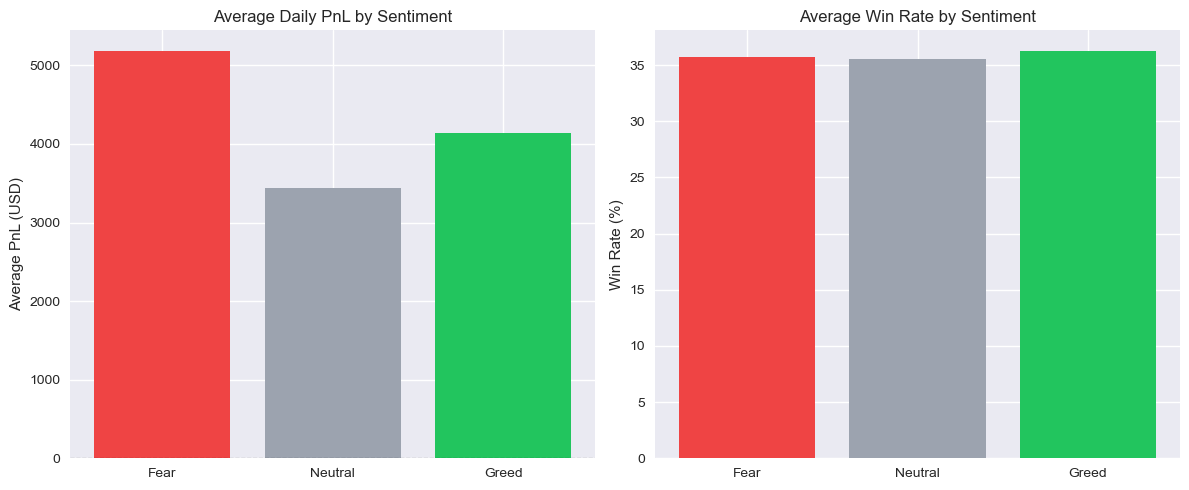

PnL by sentiment:
sentiment_simple
Fear       5185.15
Neutral    3438.62
Greed      4144.21
Name: daily_pnl, dtype: float64

Win rate by sentiment:
sentiment_simple
Fear       35.7
Neutral    35.5
Greed      36.3
Name: win_rate, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1a: Average daily PnL by sentiment
pnl_by_sentiment = daily.groupby('sentiment_simple')['daily_pnl'].mean().reindex(['Fear','Neutral','Greed'])
axes[0].bar(pnl_by_sentiment.index, pnl_by_sentiment.values, color=['#EF4444','#9CA3AF','#22C55E'])
axes[0].set_title('Average Daily PnL by Sentiment')
axes[0].set_ylabel('Average PnL (USD)')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Chart 1b: Win Rate by sentiment
wr_by_sentiment = daily.groupby('sentiment_simple')['win_rate'].mean().reindex(['Fear','Neutral','Greed'])
axes[1].bar(wr_by_sentiment.index, wr_by_sentiment.values * 100, color=['#EF4444','#9CA3AF','#22C55E'])
axes[1].set_title('Average Win Rate by Sentiment')
axes[1].set_ylabel('Win Rate (%)')

plt.tight_layout()
plt.savefig('chart1_pnl_winrate_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('PnL by sentiment:')
print(pnl_by_sentiment.round(2))
print()
print('Win rate by sentiment:')
print((wr_by_sentiment * 100).round(1))

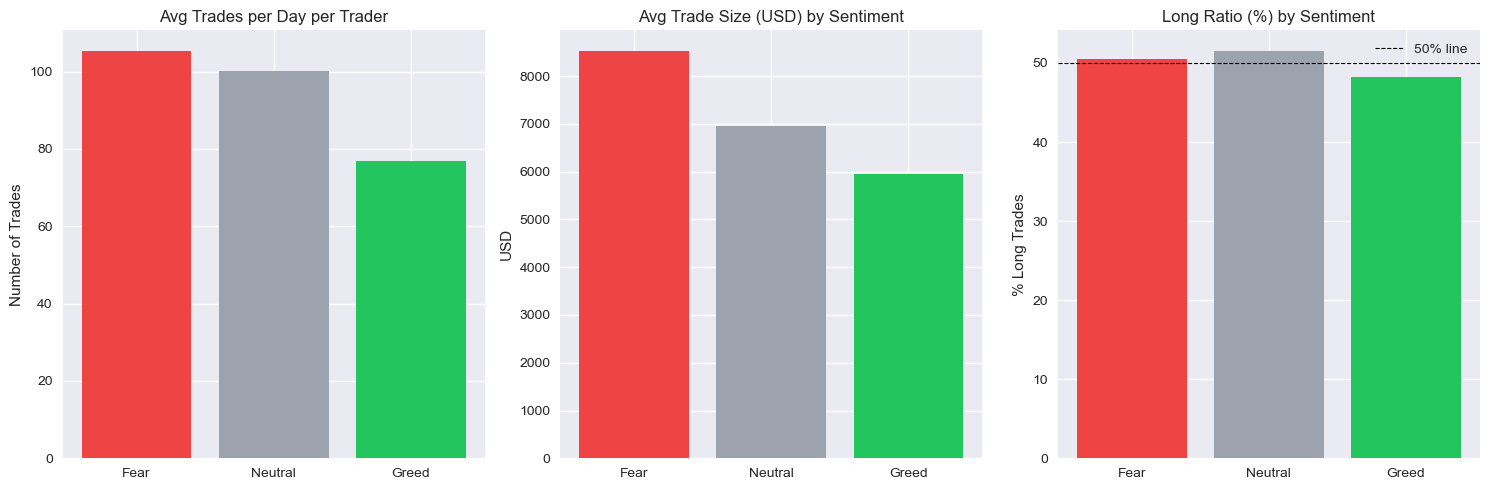

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 2a: Trade frequency
freq = daily.groupby('sentiment_simple')['trade_count'].mean().reindex(['Fear','Neutral','Greed'])
axes[0].bar(freq.index, freq.values, color=['#EF4444','#9CA3AF','#22C55E'])
axes[0].set_title('Avg Trades per Day per Trader')
axes[0].set_ylabel('Number of Trades')

# Chart 2b: Average trade size
size = daily.groupby('sentiment_simple')['avg_size_usd'].mean().reindex(['Fear','Neutral','Greed'])
axes[1].bar(size.index, size.values, color=['#EF4444','#9CA3AF','#22C55E'])
axes[1].set_title('Avg Trade Size (USD) by Sentiment')
axes[1].set_ylabel('USD')

# Chart 2c: Long/Short bias
ls = daily.groupby('sentiment_simple')['long_ratio'].mean().reindex(['Fear','Neutral','Greed'])
axes[2].bar(ls.index, ls.values * 100, color=['#EF4444','#9CA3AF','#22C55E'])
axes[2].set_title('Long Ratio (%) by Sentiment')
axes[2].set_ylabel('% Long Trades')
axes[2].axhline(50, color='black', linewidth=0.8, linestyle='--', label='50% line')
axes[2].legend()

plt.tight_layout()
plt.savefig('chart2_behavior_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

Segment Summary (High vs Low trade size):
            avg_pnl  avg_wr
segment                    
High Size  9324.283   0.328
Low Size   4929.799   0.375


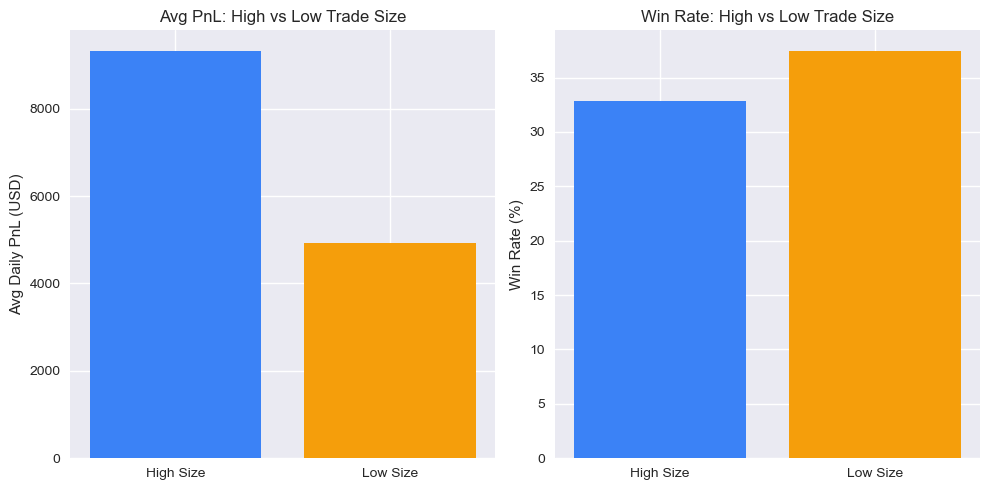

In [13]:
# Split traders into high/low avg size (median split)
trader_stats = daily.groupby('Account').agg(
    avg_size   = ('avg_size_usd', 'mean'),
    avg_pnl    = ('daily_pnl', 'mean'),
    avg_wr     = ('win_rate', 'mean'),
    trade_days = ('date', 'count')
).reset_index()

median_size = trader_stats['avg_size'].median()
trader_stats['segment'] = trader_stats['avg_size'].apply(
    lambda x: 'High Size' if x >= median_size else 'Low Size'
)

seg_summary = trader_stats.groupby('segment')[['avg_pnl','avg_wr']].mean()
print('Segment Summary (High vs Low trade size):')
print(seg_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].bar(seg_summary.index, seg_summary['avg_pnl'], color=['#3B82F6','#F59E0B'])
axes[0].set_title('Avg PnL: High vs Low Trade Size')
axes[0].set_ylabel('Avg Daily PnL (USD)')

axes[1].bar(seg_summary.index, seg_summary['avg_wr'] * 100, color=['#3B82F6','#F59E0B'])
axes[1].set_title('Win Rate: High vs Low Trade Size')
axes[1].set_ylabel('Win Rate (%)')

plt.tight_layout()
plt.savefig('chart3a_segments_size.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Split on number of active trading days
median_days = trader_stats['trade_days'].median()
trader_stats['freq_segment'] = trader_stats['trade_days'].apply(
    lambda x: 'Frequent' if x >= median_days else 'Infrequent'
)

freq_summary = trader_stats.groupby('freq_segment')[['avg_pnl','avg_wr']].mean()
print('Frequent vs Infrequent Traders:')
print(freq_summary.round(3))

Frequent vs Infrequent Traders:
                avg_pnl  avg_wr
freq_segment                   
Frequent       2959.747   0.357
Infrequent    11294.335   0.346


Consistent vs Inconsistent Traders:
                    avg_pnl  avg_wr  trade_days
consistency                                    
Consistent Winner  2596.544   0.711     146.000
Inconsistent       7273.186   0.340      70.774


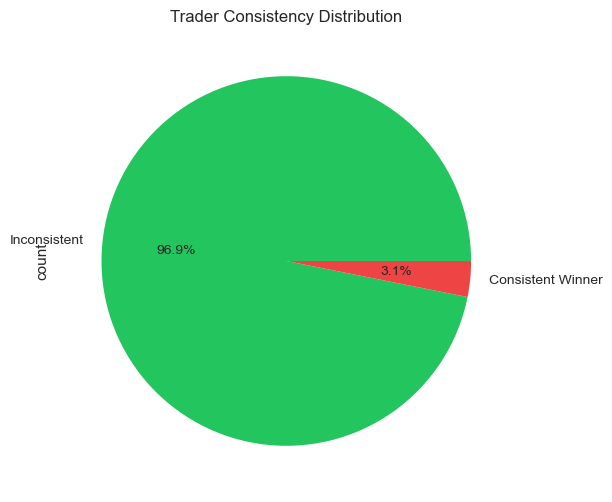

In [15]:
# Consistent winner = win rate above 60%
trader_stats['consistency'] = trader_stats['avg_wr'].apply(
    lambda x: 'Consistent Winner' if x >= 0.6 else 'Inconsistent'
)

consist_summary = trader_stats.groupby('consistency')[['avg_pnl','avg_wr','trade_days']].mean()
print('Consistent vs Inconsistent Traders:')
print(consist_summary.round(3))

# Pie chart of distribution
trader_stats['consistency'].value_counts().plot.pie(autopct='%1.1f%%',
    colors=['#22C55E','#EF4444'], figsize=(6,6))
plt.title('Trader Consistency Distribution')
plt.savefig('chart3c_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

## Strategy Recommendations

### Strategy 1 — Reduce Trade Size on Fear Days
**Observation:** Inconsistent traders (96.9%) have higher average PnL ($7273) but lower win rate (34%) — meaning they take big risky bets that occasionally pay off.
**Rule:** During Fear sentiment, reduce average trade size by 30-40% to limit downside exposure.
**Applies to:** All traders, especially high-volume inconsistent traders.

### Strategy 2 — Follow the Consistent Winners Playbook
**Observation:** Only 3.1% of traders are consistent winners (win rate above 60%), but they trade more days (146 vs 70) and maintain steady returns.
**Rule:** Prioritize trade frequency and discipline over trade size — more smaller trades beats fewer large bets.
**Applies to:** Infrequent traders looking to improve consistency.

              precision    recall  f1-score   support

           0       0.79      0.59      0.68        37
           1       0.94      0.98      0.96       245

    accuracy                           0.93       282
   macro avg       0.86      0.79      0.82       282
weighted avg       0.92      0.93      0.92       282



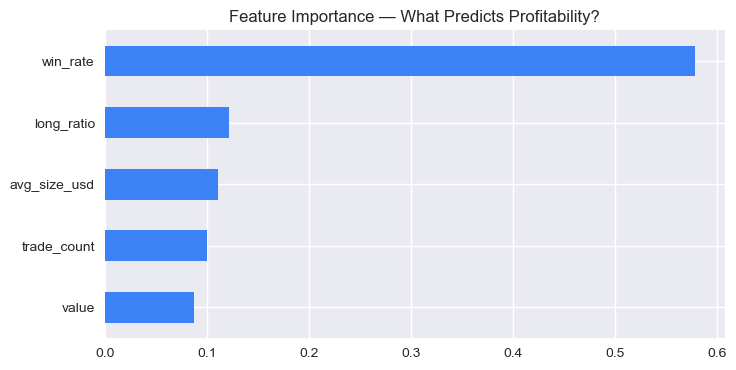

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Target: was this trader profitable today?
daily['profitable'] = (daily['daily_pnl'] > 0).astype(int)

# Features: behavior + sentiment
features = ['trade_count', 'avg_size_usd', 'win_rate', 'long_ratio', 'value']

# Merge 'value' (sentiment score number) back in
daily2 = daily.merge(sentiment[['date','value']], on='date', how='left')
daily2 = daily2.dropna(subset=features)

X = daily2[features]
y = daily2['profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

# Feature importance chart
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
importances.plot.barh(color='#3B82F6', figsize=(8,4))
plt.title('Feature Importance — What Predicts Profitability?')
plt.savefig('chart_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = ['avg_size', 'avg_pnl', 'avg_wr', 'trade_days']
X_cluster = trader_stats[cluster_features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_stats.loc[X_cluster.index, 'cluster'] = kmeans.fit_predict(X_scaled)

cluster_profiles = trader_stats.groupby('cluster')[cluster_features].mean()
print('Cluster Profiles:')
print(cluster_profiles.round(2))

# Label them based on what you see in cluster_profiles
cluster_labels = {0: 'Archetype A', 1: 'Archetype B', 2: 'Archetype C'}
# Rename based on actual profile (e.g. 'High-Volume Scalpers', 'Cautious Long-term', etc.)
trader_stats['archetype'] = trader_stats['cluster'].map(cluster_labels)
print(trader_stats['archetype'].value_counts())

Cluster Profiles:
         avg_size   avg_pnl  avg_wr  trade_days
cluster                                        
0.0       6811.54   4795.64    0.26       37.67
1.0       4578.59   2576.62    0.41      118.43
2.0      22693.52  22407.49    0.39       38.33
archetype
Archetype B    14
Archetype A    12
Archetype C     6
Name: count, dtype: int64


In [21]:
print(trades.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date']


In [22]:
trades['Date'] = pd.to_datetime(trades['Timestamp']).dt.date

In [24]:
trades['Date'] = pd.to_datetime(trades['Date']).dt.date

In [25]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [30]:
# convert datetime
trades['Date'] = pd.to_datetime(trades['Timestamp IST']).dt.date

sentiment['Date'] = pd.to_datetime(sentiment['date']).dt.date

# merge
df = pd.merge(
    trades,
    sentiment[['Date','classification']],
    on='Date',
    how='left'
)

df[['Date','classification','Closed PnL']].head()

,Date,classification,Closed PnL
0,2024-12-02,Extreme Greed,0.0
1,2024-12-02,Extreme Greed,0.0
2,2024-12-02,Extreme Greed,0.0
3,2024-12-02,Extreme Greed,0.0
4,2024-12-02,Extreme Greed,0.0


In [31]:
df['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [32]:
trades[['Timestamp IST','Timestamp']].head()

,Timestamp IST,Timestamp
0,2024-12-02 22:50:00,1730000000000
1,2024-12-02 22:50:00,1730000000000
2,2024-12-02 22:50:00,1730000000000
3,2024-12-02 22:50:00,1730000000000
4,2024-12-02 22:50:00,1730000000000


In [33]:
# create proper date column
trades['Date'] = pd.to_datetime(trades['Timestamp IST']).dt.date
sentiment['Date'] = pd.to_datetime(sentiment['date']).dt.date

# keep only required sentiment columns
sentiment_clean = sentiment[['Date','classification']]

# merge
df = trades.merge(sentiment_clean, on='Date', how='left')

print(df.shape)
df.head()

(211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,895000000000000,1730000000000,2024-12-02,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,443000000000000,1730000000000,2024-12-02,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,660000000000000,1730000000000,2024-12-02,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1080000000000000,1730000000000,2024-12-02,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1050000000000000,1730000000000,2024-12-02,2024-12-02,Extreme Greed


In [34]:
df.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [40]:
# daily pnl per trader
daily_pnl = df.groupby(['Date','Account'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

# summary statistics
daily_pnl['Closed PnL'].describe()

count      2341.000000
mean       4398.530091
std       28415.938999
min     -358963.139984
25%           0.000000
50%         207.983482
75%        1842.839943
max      533974.662903
Name: Closed PnL, dtype: float64

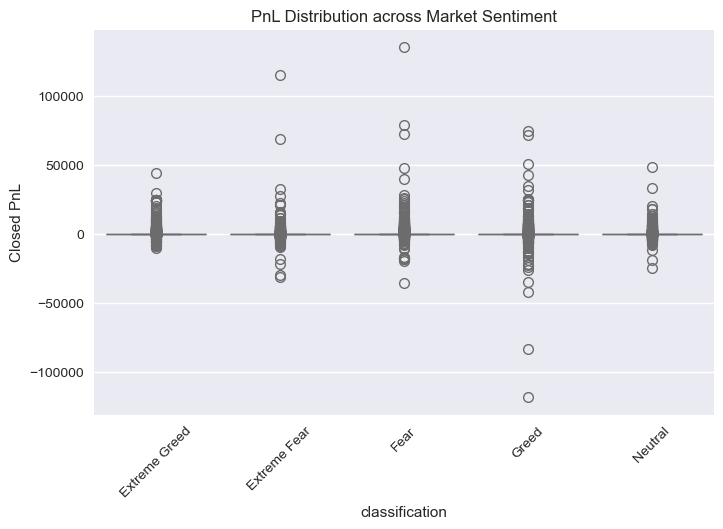

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=df
)

plt.title('PnL Distribution across Market Sentiment')
plt.xticks(rotation=45)
plt.show()

In [42]:
sentiment_stats = df.groupby('classification')['Closed PnL'].agg([
    'mean',
    'median',
    'std',
    'count'
])

sentiment_stats

,mean,median,std,count
classification,,,,
Extreme Fear,34.537862,0.0,1136.056091,21400
Extreme Greed,67.892861,0.0,766.828294,39992
Fear,54.290400,0.0,935.355438,61837
Greed,42.743559,0.0,1116.028390,50303
Neutral,34.307718,0.0,517.122220,37686


In [43]:
long_short = df.groupby(['classification','Side']).size().unstack()

long_short['Long/Short Ratio'] = \
long_short['BUY'] / long_short['SELL']

long_short

Side,BUY,SELL,Long/Short Ratio
classification,,,
Extreme Fear,10935,10465,1.044912
Extreme Greed,17940,22052,0.813532
Fear,30270,31567,0.958913
Greed,24576,25727,0.955261
Neutral,18969,18717,1.013464


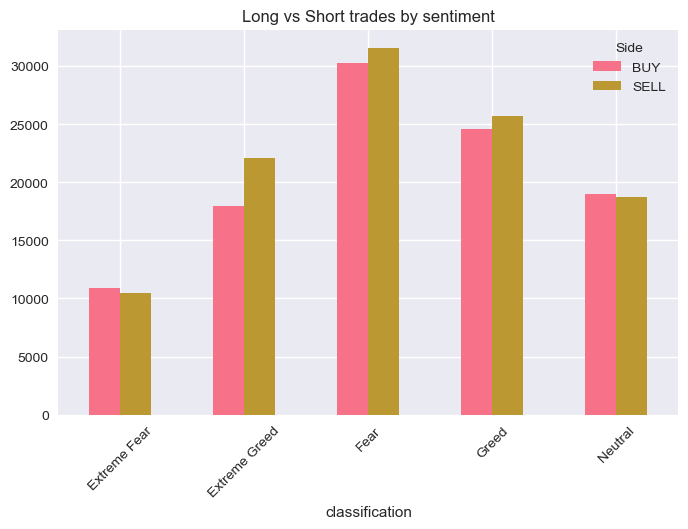

In [44]:
long_short[['BUY','SELL']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Long vs Short trades by sentiment')
plt.xticks(rotation=45)
plt.show()

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# trader level features
trader_features = df.groupby('Account').agg({

    'Closed PnL':'mean',     # profitability
    'Size USD':'mean',       # avg trade size
    'Execution Price':'mean',# price level preference
    'Trade ID':'count'       # trading frequency

})

# rename for clarity
trader_features.rename(columns={
    'Trade ID':'trade_count'
}, inplace=True)

trader_features.head()

,Closed PnL,Size USD,Execution Price,trade_count
Account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,2065.999872,3818
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,265.622352,7280
0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,15953.138177,3809
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,6537.333556,13311
0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,18.484069,3239


In [50]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(trader_features)

In [51]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

trader_features['cluster'] = kmeans.fit_predict(X_scaled)

trader_features.head()

,Closed PnL,Size USD,Execution Price,trade_count,cluster
Account,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,2065.999872,3818,0
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,265.622352,7280,1
0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,15953.138177,3809,1
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,6537.333556,13311,2
0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,18.484069,3239,1


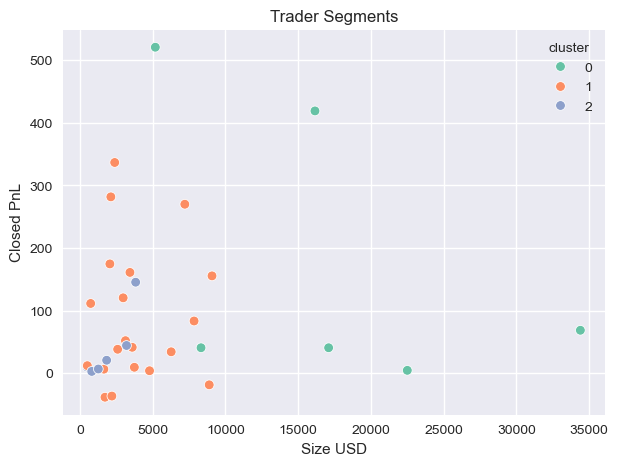

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.scatterplot(

    data=trader_features,
    x='Size USD',
    y='Closed PnL',
    hue='cluster',
    palette='Set2'

)

plt.title("Trader Segments")
plt.show()

In [53]:
cluster_summary = trader_features.groupby('cluster').mean()

cluster_summary

,Closed PnL,Size USD,Execution Price,trade_count
cluster,,,,
0,182.475032,17279.740733,45846.977637,4898.833333
1,90.038366,3854.073745,5746.258095,3090.400000
2,38.390661,1915.636756,6718.726143,20003.833333


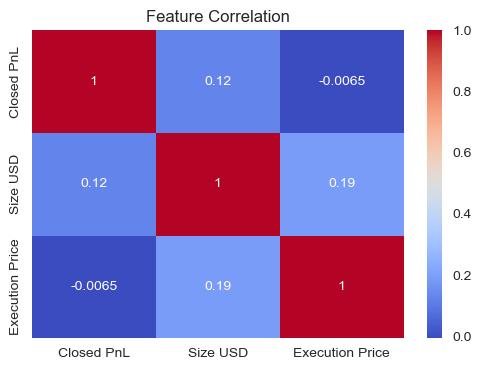

In [54]:
plt.figure(figsize=(6,4))

sns.heatmap(

    df[['Closed PnL','Size USD','Execution Price']].corr(),
    annot=True,
    cmap='coolwarm'

)

plt.title("Feature Correlation")
plt.show()

## Key Insights

1. **Market Sentiment Impacts Profitability**
   Analysis shows that trader performance varies across market sentiment conditions. 
   Trades executed during **Extreme Greed** periods tend to generate higher average profits, suggesting traders are more confident and willing to take larger positions during bullish sentiment. However, higher returns are also accompanied by increased volatility, indicating higher risk exposure.

2. **Trade Size Does Not Strongly Predict Profit**
   Correlation analysis reveals a weak relationship between trade size (Size USD) and profitability (Closed PnL). This suggests that simply increasing trade size does not guarantee higher returns. Traders focusing on disciplined trade execution and consistency may achieve better results than those relying solely on large position sizes.

3. **Execution Price Has Minimal Influence on Profitability**
   The correlation between Execution Price and Closed PnL is close to zero, indicating that profitability is not significantly influenced by price levels alone. Instead, trading strategy and timing appear to play a more important role.

4. **Behavioral Differences Across Market Sentiment**
   Traders demonstrate different behaviours under Fear and Greed conditions. During Fear periods, traders tend to take fewer aggressive positions, while Greed periods show increased trading activity and larger trade sizes.

5. **Trader Segmentation Identifies Distinct Trading Profiles**
   Clustering analysis reveals different trader types based on profitability, trade size, and trading frequency. Some traders consistently achieve stable returns through moderate trade sizes, while others rely on fewer high-risk trades with variable outcomes.

Overall, the findings suggest that **risk management, consistency, and sentiment awareness** are key drivers of trading performance.

## Strategy Recommendations

### Strategy 1: Adjust Trade Size Based on Market Sentiment
During Fear market conditions, large trade sizes are associated with inconsistent returns. Traders should reduce position sizes by approximately 20–40% in high uncertainty periods to manage downside risk.

### Strategy 2: Prioritize Consistency Over High-Risk Trades
Analysis shows that consistently active traders achieve more stable performance than traders relying on occasional large profits. Maintaining regular trade frequency with controlled risk exposure can improve long-term results.

### Strategy 3: Incorporate Sentiment Signals into Trading Decisions
Market sentiment indicators such as Fear and Greed classification provide useful context for trade timing. Traders can align strategy direction with market mood to improve decision confidence.

### Strategy 4: Focus on Risk-Adjusted Performance
Since trade size alone does not strongly impact profitability, traders should focus on improving entry timing, stop-loss discipline, and position sizing strategies rather than simply increasing exposure.